# Extração

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
# Extração dos dados por meio de uma API
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
resposta = requests.get(url)
dados = resposta.json()
df = pd.json_normalize(dados)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Tratamento

In [3]:
# Conferindo se há linhas com espaços vazios e os substitui para valores nulos
df = df.replace(r'^\s*$', np.nan, regex=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
# Removendo as linhas com valores nulos
df.dropna(inplace=True)

# Renomeando colunas de forma otimizada
df.columns = df.columns.str.replace('.', '_')

# Garantindo que Total Charges seja número (float)
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'])

# Criando a coluna de cobrança diária
df['account_Charges_Daily'] = round(df['account_Charges_Monthly'] / 30, 2)

# Convertendo categóricas para números inteiros 
colunas_categoricas = ['Churn', 
                       'customer_Partner', 
                       'customer_Dependents', 
                       'phone_PhoneService',
                       'account_PaperlessBilling']

df[colunas_categoricas] = df[colunas_categoricas].replace({'Yes': 1, 'No': 0})

# Verificando se agora são int e float
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer_gender            7032 non-null   object 
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   int64  
 5   customer_Dependents        7032 non-null   int64  
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   int64  
 8   phone_MultipleLines        7032 non-null   object 
 9   internet_InternetService   7032 non-null   object 
 10  internet_OnlineSecurity    7032 non-null   object 
 11  internet_OnlineBackup      7032 non-null   object 
 12  internet_DeviceProtection  7032 non-null   object 
 13  internet_TechSupport       7032 non-null   object 
 1

C:\Users\Enrico\AppData\Local\Temp\ipykernel_21080\3872283155.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colunas_categoricas] = df[colunas_categoricas].replace({'Yes': 1, 'No': 0})


# Carga e análise

In [5]:
# Estatísticas descritivas de dados quantitativos
df.describe()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,account_Charges_Daily
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [6]:
# Estatísticas descritivas de dados do tipo object
df.describe(include=['O'])

,customerID,customer_gender,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


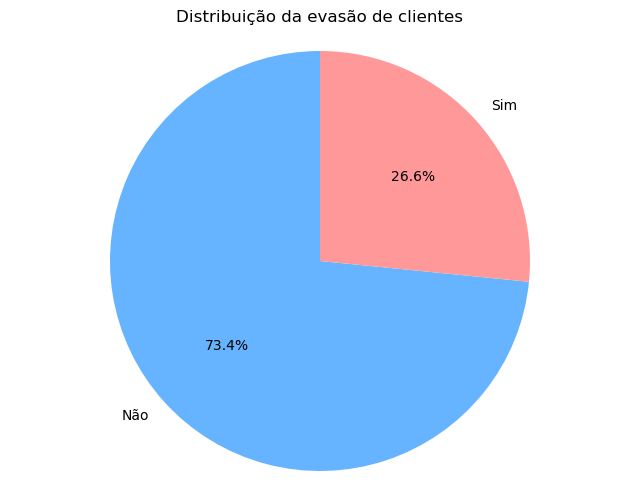

In [7]:
# Gráfico de pizza que mostra a distribuição de evasão de clientes
fig = plt.figure(figsize=(8,6))
plt.pie(df['Churn'].value_counts(), labels=['Não', 'Sim'], startangle=90, autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title('Distribuição da evasão de clientes')
plt.axis('equal')
plt.show()

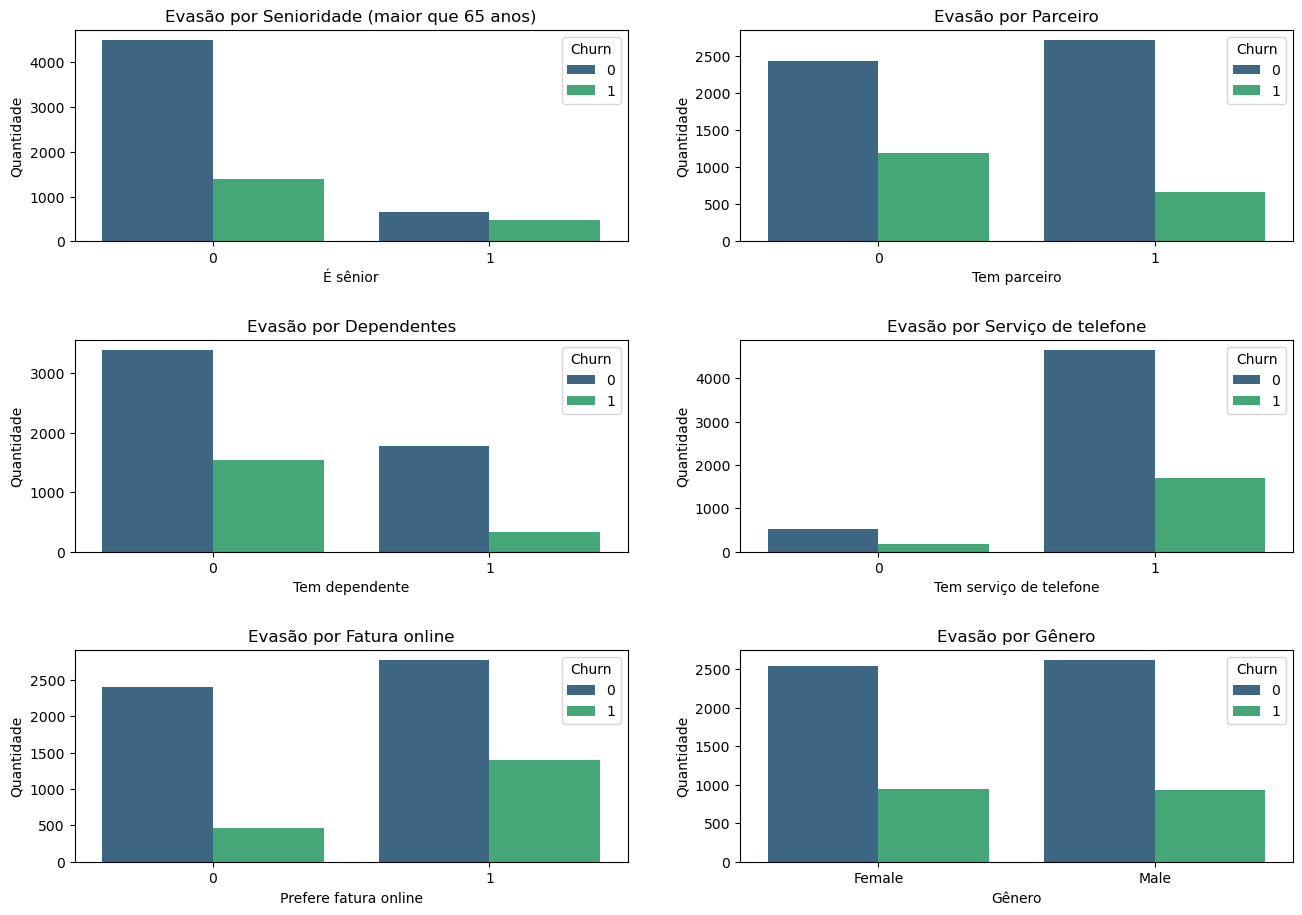

In [8]:
# Gráficos de colunas que comparam as relações entre a evasão de clientes e diversar variáveis categóricas
colunas_categoricas_para_analisar = ['customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 
                         'phone_PhoneService', 'account_PaperlessBilling', 'customer_gender']
traducao_colunas = ['Senioridade (maior que 65 anos)', 'Parceiro', 'Dependentes', 'Serviço de telefone',
                    'Fatura online', 'Gênero']
x_labels = ['É sênior', 'Tem parceiro', 'Tem dependente', 'Tem serviço de telefone', 'Prefere fatura online', 'Gênero']

fig, ax = plt.subplots(3, 2, figsize=(14, 10))

plt.tight_layout(pad=5.0) 

for i, coluna in enumerate(colunas_categoricas_para_analisar):
    sns.countplot(data=df, x=coluna, hue='Churn', palette='viridis', 
        ax=ax.flatten()[i])
    ax.flatten()[i].set_title(f'Evasão por {traducao_colunas[i]}')
    ax.flatten()[i].set_ylabel('Quantidade')
    ax.flatten()[i].set_xlabel(f'{x_labels[i]}')

plt.show()

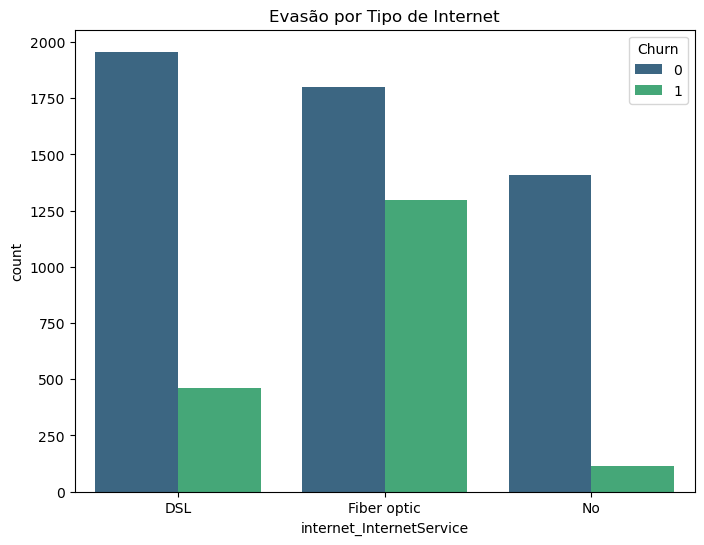

In [9]:
# Gráfico que analisa a relação do tipo de internet do cliente com a evasão
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='internet_InternetService', hue='Churn', palette='viridis')
plt.title('Evasão por Tipo de Internet')
plt.show()

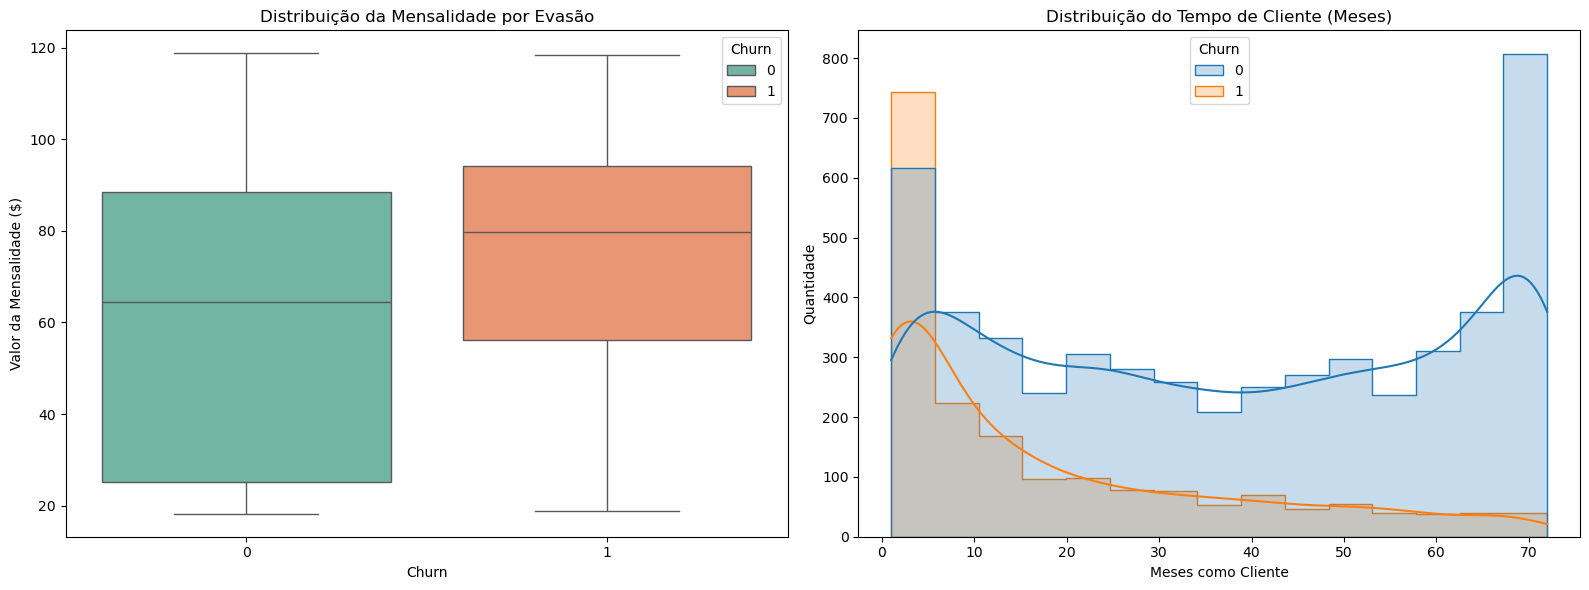

In [10]:
# Gráficos que analisam a relação entre a evasão de clientes e variáveis númericas
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico box plot que mostra a distribuição de mensalidade por evasão do cliente
sns.boxplot(data=df, x='Churn', y='account_Charges_Monthly', hue='Churn', palette='Set2', ax=ax[0])
ax[0].set_title('Distribuição da Mensalidade por Evasão')
ax[0].set_ylabel('Valor da Mensalidade ($)')

# Gráfico histograma que mostra a distribuição de tempo de contrato por evasão do cliente
sns.histplot(data=df, x='customer_tenure', hue='Churn', kde=True, element="step", ax=ax[1])
ax[1].set_title('Distribuição do Tempo de Cliente (Meses)')
ax[1].set_xlabel('Meses como Cliente')
ax[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

In [11]:
# Cria a matriz de correlação entre as variavéis númericas e mostra as correlações entre a evasão de clientes
corr_matrix = df.corr(numeric_only=True)
df.corr(numeric_only=True).iloc[1:,0].round(2)

customer_SeniorCitizen      0.15
customer_Partner           -0.15
customer_Dependents        -0.16
customer_tenure            -0.35
phone_PhoneService          0.01
account_PaperlessBilling    0.19
account_Charges_Monthly     0.19
account_Charges_Total      -0.20
account_Charges_Daily       0.19
Name: Churn, dtype: float64

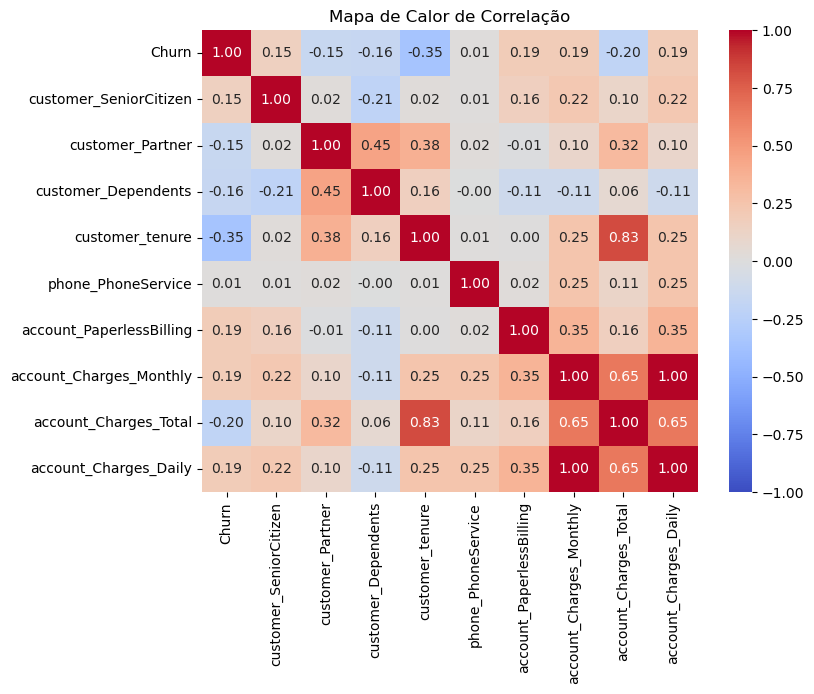

In [12]:
# Mapa de calor que mostra as correlações entre variáveis númericas do dataset
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Mapa de Calor de Correlação")
plt.show()

# Relatório

## 1. Introdução e Objetivo
O objetivo deste projeto é analisar a evasão de clientes **(Churn)** da Telecom X, motivada pelo alto índice de cancelamentos registrados nos últimos meses. Esta análise procura transformar dados brutos em insights estratégicos para apoiar a tomada de decisão e reduzir a perda de receita.
## 2. Metodologia: Tratamento de Dados (ETL)
A importação dos dados foi realizada via API (formato JSON), seguida de um processo rigoroso de normalização e limpeza:
* **Limpeza:** Eliminação de valores nulos e tratamento de espaços em branco (strings vazias).
* **Transformação:** Conversão de colunas binárias (Sim/Não) para numéricas (1/0) e ajuste de tipos de dados (texto para números).
* **Engenharia de Atributos:** Criação de colunas auxiliares (ex: Cobrança Diária) e renomeação de variáveis para facilitar a manipulação.
## 3. Análise Exploratória (EDA)
Para compreender o perfil do cliente, utilizamos estatísticas descritivas (média, moda, percentis) e visualizações estratégicas:
* **Proporção de Evasão:** Gráfico de Pizza.
* **Análise Categórica:** Gráficos de Barras para identificar relações em atributos como Género e Serviços.
* **Análise Numérica:** Boxplots e Histogramas para avaliar o impacto da Mensalidade e do Tempo de Contrato.
* **Correlações:** Mapa de Calor para visualizar a força das relações entre variáveis numéricas.
## 4. Principais Insights e Conclusões
A análise dos gráficos revelou padrões claros de comportamento:
* **Fator Crítico - Tempo de Casa (Tenure):** A relação mais evidente. A maior parte dos cancelamentos ocorre entre clientes recentes (menos de 10 meses de contrato). Clientes antigos tendem a ser fiéis.
* **Fator Financeiro:** O Boxplot indica que clientes que cancelam pagam, em média, mensalidades mais altas do que os que permanecem.
* **Serviços de Risco:**
    * **Fibra Óptica:** Clientes com este serviço têm uma probabilidade significativamente maior de cancelar, sugerindo problemas técnicos ou preço desajustado.
    * **Fatura Online:** Clientes que optam por fatura digital (paperless) apresentam maior taxa de evasão.
* **Demografia:** O gênero é irrelevante para o Churn. Por outro lado, clientes seniores (idosos) cancelam mais, enquanto clientes com dependentes/parceiros cancelam menos.
## 5. Recomendações Estratégicas
Com base nos dados, sugerimos as seguintes ações para a Telecom X:
1. **Foco na Retenção Inicial:** Criar descontos progressivos ou programas de onboarding para novos clientes, visando superar a barreira crítica dos primeiros 10 meses.
2. **Revisão da Fibra Óptica:** Investigar urgentemente a qualidade técnica e a competitividade do preço do serviço de fibra, visto ser um grande ofensor.
3. **Melhoria da Experiência Digital:** Analisar o processo de fatura online (Paperless). A alta evasão neste grupo pode indicar dificuldades na plataforma de pagamento ou falta de lembretes eficazes.

